# 02 — Results: model comparison across horizons

Loads saved per-fold predictions written by `run_experiments.py` and renders:
1. A side-by-side metrics summary table (RMSE, QLIKE, directional accuracy) for every
   model x horizon combination.
2. Actual-vs-predicted plots for each model x horizon.
3. SHAP feature-importance plots for the LightGBM models.

Run `python run_experiments.py` from the project root before this notebook.

In [12]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_DIR = Path.cwd().parent if (Path.cwd() / 'notebooks').exists() is False else Path.cwd()
if PROJECT_DIR.name == 'notebooks':
    PROJECT_DIR = PROJECT_DIR.parent
sys.path.insert(0, str(PROJECT_DIR))

PRED_DIR = PROJECT_DIR / 'data' / 'predictions'
SUMMARY_DIR = PROJECT_DIR / 'artifacts' / 'summary'
PLOT_DIR = PROJECT_DIR / 'artifacts' / 'plots'
MODELS = ['naive', 'garch', 'lgbm', 'lstm']
HORIZONS = [1, 5, 21]

## Metrics summary table

In [13]:
summary_long = pd.read_csv(SUMMARY_DIR / 'metrics_summary.csv')
wide = summary_long.pivot_table(index='model', columns=['horizon', 'metric'], values='value')
wide = wide.reindex([m for m in MODELS if m in wide.index])
wide.style.format('{:.4f}').background_gradient(axis=0, cmap='RdYlGn_r', subset=pd.IndexSlice[:, pd.IndexSlice[:, ['rmse', 'qlike']]]).background_gradient(axis=0, cmap='RdYlGn', subset=pd.IndexSlice[:, pd.IndexSlice[:, 'dir_acc']])

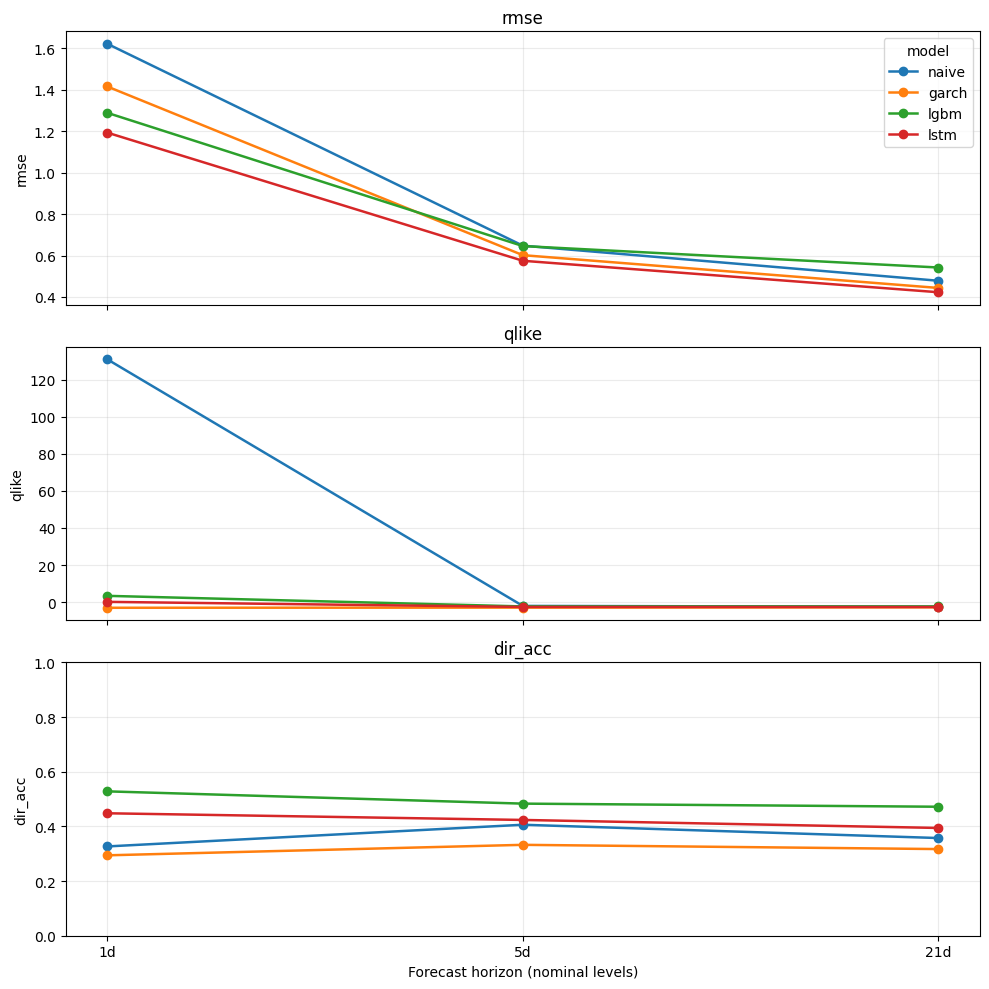

In [14]:
# Visual comparison: one plot per metric, x-axis=horizon (nominal/equal-spaced), line=model.
plot_df = summary_long.copy()
plot_df['model'] = pd.Categorical(plot_df['model'], categories=MODELS, ordered=True)
metrics = ['rmse', 'qlike', 'dir_acc']

horizon_levels = [1, 5, 21]
x_pos = np.arange(len(horizon_levels))
x_labels = [f'{h}d' for h in horizon_levels]
horizon_to_x = {h: i for i, h in enumerate(horizon_levels)}

fig, axes = plt.subplots(len(metrics), 1, figsize=(10, 10), sharex=True)
for ax, metric in zip(axes, metrics):
    sub = plot_df[plot_df['metric'] == metric].copy()
    if sub.empty:
        ax.set_title(f'{metric} (no data)')
        continue

    for model in MODELS:
        msub = sub[sub['model'] == model].copy()
        if msub.empty:
            continue
        msub = msub[msub['horizon'].isin(horizon_levels)].sort_values('horizon')
        if msub.empty:
            continue
        x = msub['horizon'].map(horizon_to_x).to_numpy()
        y = msub['value'].to_numpy()
        ax.plot(x, y, marker='o', linewidth=1.8, label=model)

    ax.set_title(metric)
    ax.set_ylabel(metric)
    ax.grid(alpha=0.25)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labels)

    if metric == 'dir_acc':
        ax.set_ylim(0, 1)

axes[-1].set_xlabel('Forecast horizon (nominal levels)')
axes[0].legend(title='model', loc='best')
plt.tight_layout()
plt.show()

## Comparison dashboard: heatmaps + composite score

This dashboard adds three complementary views:
- Raw metric heatmaps (`model x horizon`) for each metric.
- Rank heatmaps (1=best per horizon/metric).
- Composite score from normalized metrics so different scales are comparable.

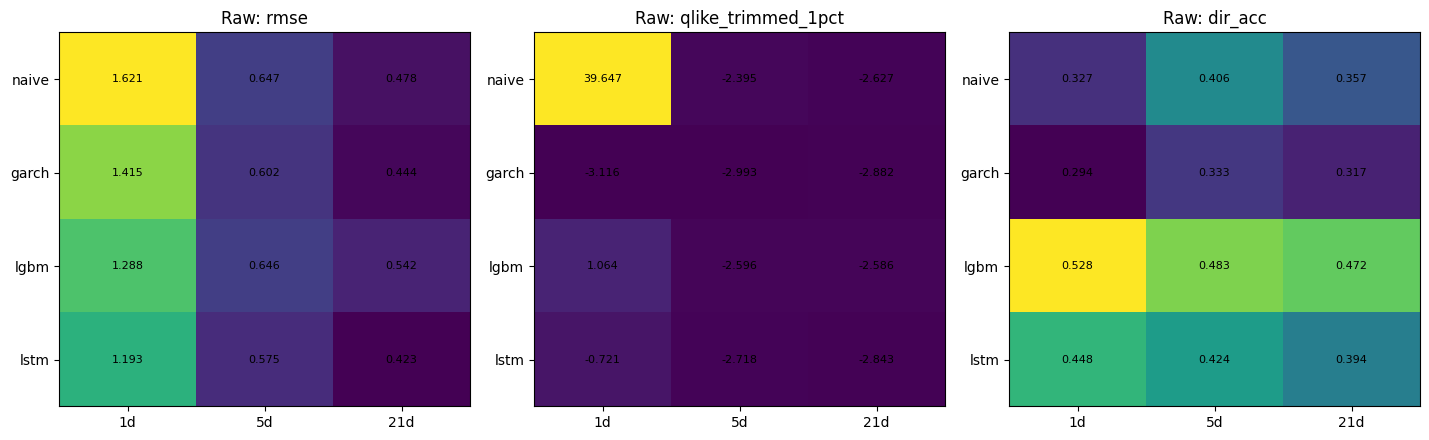

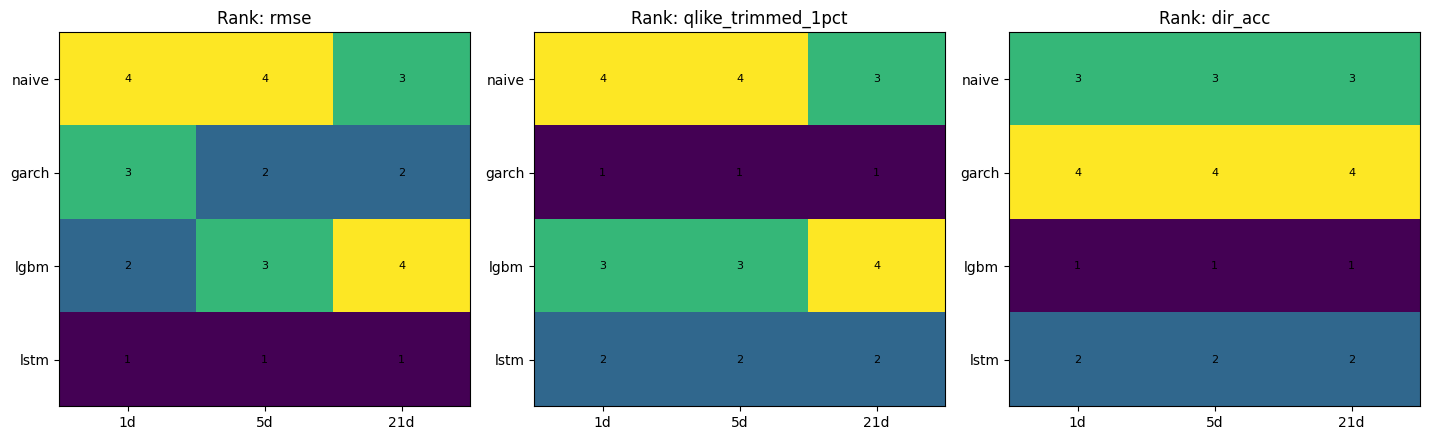

Composite score (higher is better):


,model,composite_score
2,lstm,0.681934
1,lgbm,0.141378
0,garch,0.048468
3,naive,-0.871780


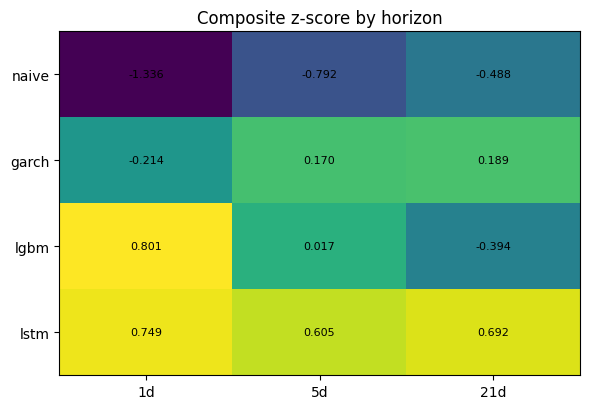

In [15]:
# Heatmaps and composite score view
metrics_for_dashboard = ['rmse', 'qlike_trimmed_1pct', 'dir_acc']
lower_is_better = {'rmse': True, 'qlike_trimmed_1pct': True, 'dir_acc': False}

# Keep only metrics that actually exist in summary_long so the cell is robust.
metrics_present = [m for m in metrics_for_dashboard if m in set(summary_long['metric'])]
if not metrics_present:
    raise ValueError('None of the dashboard metrics are present in summary_long.')

horizons_sorted = sorted(summary_long['horizon'].unique())
models_present = [m for m in MODELS if m in set(summary_long['model'])]

def _pivot_metric(metric_name: str) -> pd.DataFrame:
    p = summary_long[summary_long['metric'] == metric_name].pivot_table(
        index='model', columns='horizon', values='value'
    )
    p = p.reindex(index=models_present, columns=horizons_sorted)
    return p

def _draw_heatmap(ax, mat: np.ndarray, row_labels, col_labels, title: str, fmt: str = '.3f'):
    im = ax.imshow(mat, aspect='auto')
    ax.set_title(title)
    ax.set_xticks(np.arange(len(col_labels)))
    ax.set_yticks(np.arange(len(row_labels)))
    ax.set_xticklabels([f'{h}d' for h in col_labels])
    ax.set_yticklabels(row_labels)
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            v = mat[i, j]
            txt = 'nan' if not np.isfinite(v) else format(v, fmt)
            ax.text(j, i, txt, ha='center', va='center', fontsize=8)
    return im

# 1) Raw metric heatmaps
fig, axes = plt.subplots(1, len(metrics_present), figsize=(4.8 * len(metrics_present), 4.5), squeeze=False)
for ax, metric_name in zip(axes[0], metrics_present):
    pv = _pivot_metric(metric_name)
    _draw_heatmap(ax, pv.to_numpy(dtype=float), pv.index.tolist(), pv.columns.tolist(), f'Raw: {metric_name}')
plt.tight_layout()
plt.show()

# 2) Rank heatmaps (1 = best)
fig, axes = plt.subplots(1, len(metrics_present), figsize=(4.8 * len(metrics_present), 4.5), squeeze=False)
for ax, metric_name in zip(axes[0], metrics_present):
    pv = _pivot_metric(metric_name)
    asc = lower_is_better.get(metric_name, True)
    ranks = pv.rank(axis=0, method='min', ascending=asc)
    _draw_heatmap(ax, ranks.to_numpy(dtype=float), ranks.index.tolist(), ranks.columns.tolist(), f'Rank: {metric_name}', fmt='.0f')
plt.tight_layout()
plt.show()

# 3) Composite score from per-(metric,horizon) z-scores
#    For lower-is-better metrics, multiply by -1 so higher composite is better.
z_rows = []
for h in horizons_sorted:
    for metric_name in metrics_present:
        sub = summary_long[(summary_long['horizon'] == h) & (summary_long['metric'] == metric_name)].copy()
        if sub.empty:
            continue
        mu = sub['value'].mean()
        sigma = sub['value'].std(ddof=0)
        if sigma == 0 or not np.isfinite(sigma):
            sub['z'] = 0.0
        else:
            sub['z'] = (sub['value'] - mu) / sigma
        if lower_is_better.get(metric_name, True):
            sub['z'] = -sub['z']
        z_rows.append(sub[['model', 'horizon', 'metric', 'z']])

z_df = pd.concat(z_rows, ignore_index=True)
composite = z_df.groupby('model', as_index=False)['z'].mean().rename(columns={'z': 'composite_score'})
composite = composite.sort_values('composite_score', ascending=False)
print('Composite score (higher is better):')
display(composite)

comp_pivot = z_df.pivot_table(index='model', columns='horizon', values='z', aggfunc='mean')
comp_pivot = comp_pivot.reindex(index=models_present, columns=horizons_sorted)

fig, ax = plt.subplots(figsize=(6, 4.2))
_draw_heatmap(ax, comp_pivot.to_numpy(dtype=float), comp_pivot.index.tolist(), comp_pivot.columns.tolist(), 'Composite z-score by horizon')
plt.tight_layout()
plt.show()

## Actual vs. predicted, per model and horizon

We concatenate predictions across folds; the time axis covers each model's full set of
validation predictions.

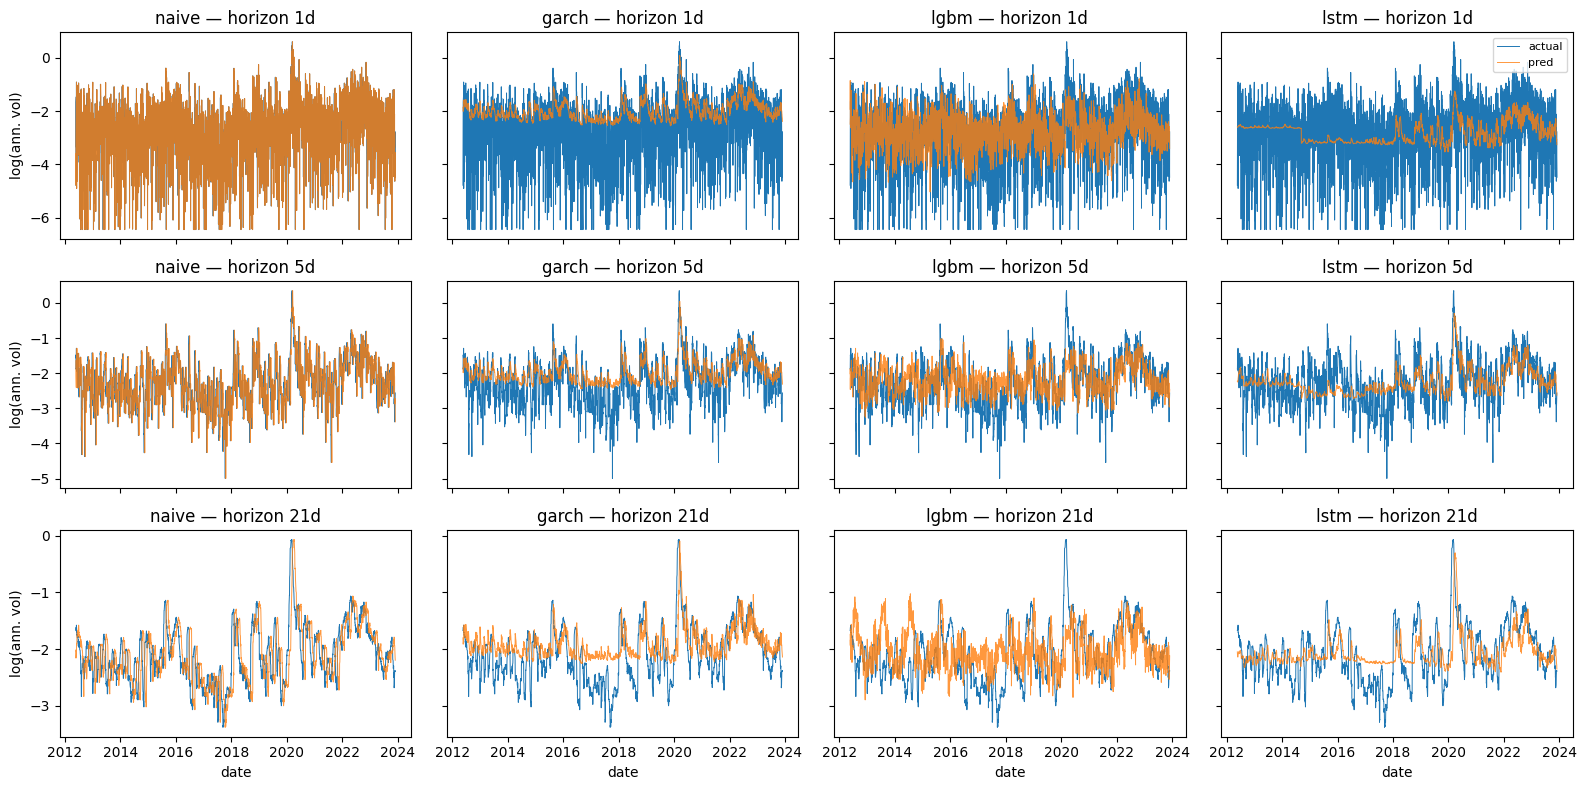

In [16]:
def load_all(model: str, horizon: int) -> pd.DataFrame:
    p = PRED_DIR / f'{model}_{horizon}d_all.csv'
    if not p.exists():
        return pd.DataFrame(columns=['date', 'y_true', 'y_pred'])
    df = pd.read_csv(p, parse_dates=['date']).sort_values('date')
    return df

fig, axes = plt.subplots(len(HORIZONS), len(MODELS), figsize=(16, 8), sharex=True, sharey='row')
for r, h in enumerate(HORIZONS):
    for c, m in enumerate(MODELS):
        ax = axes[r, c]
        df = load_all(m, h)
        if df.empty:
            ax.set_title(f'{m} h={h}d (no preds)')
            continue
        ax.plot(df['date'], df['y_true'], lw=0.7, label='actual')
        ax.plot(df['date'], df['y_pred'], lw=0.7, label='pred', alpha=0.8)
        ax.set_title(f'{m} — horizon {h}d')
        if r == 0 and c == len(MODELS) - 1:
            ax.legend(loc='upper right', fontsize=8)
for ax in axes[-1, :]:
    ax.set_xlabel('date')
for ax in axes[:, 0]:
    ax.set_ylabel('log(ann. vol)')
plt.tight_layout()
plt.show()

## SHAP — LightGBM feature importance per horizon

Saved during `run_experiments.py` from the last fold's validation slice.

Horizon 1d:


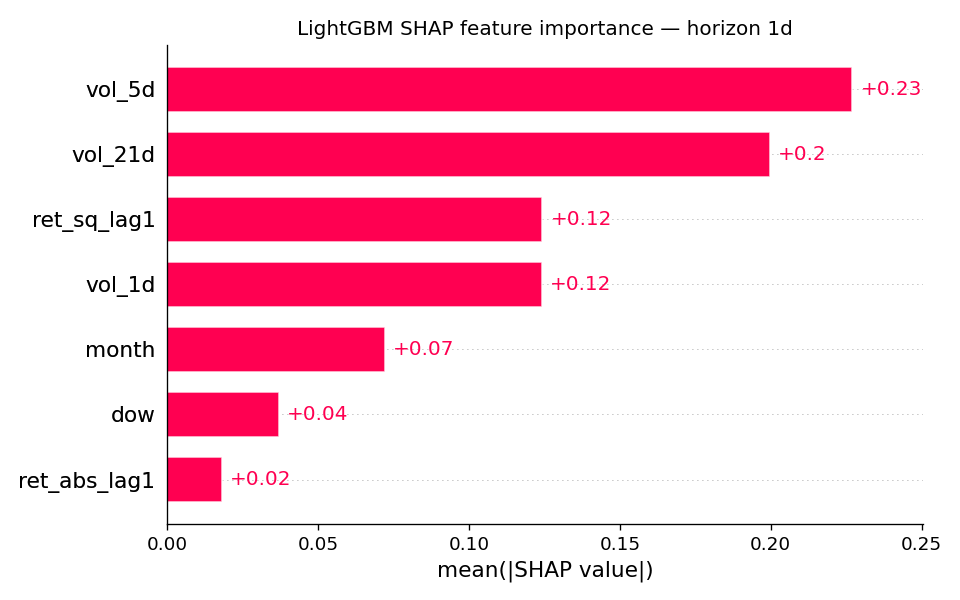

Horizon 5d:


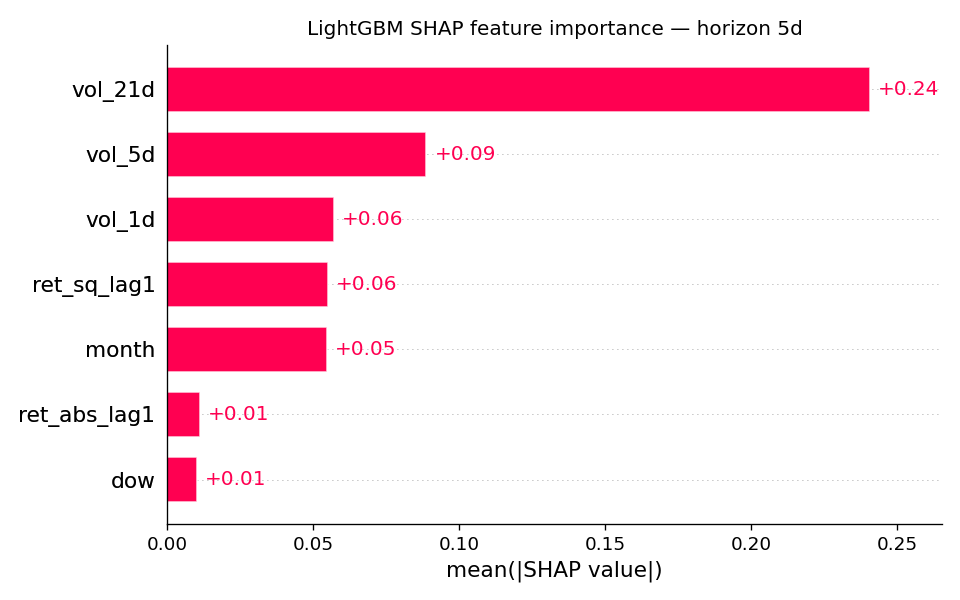

Horizon 21d:


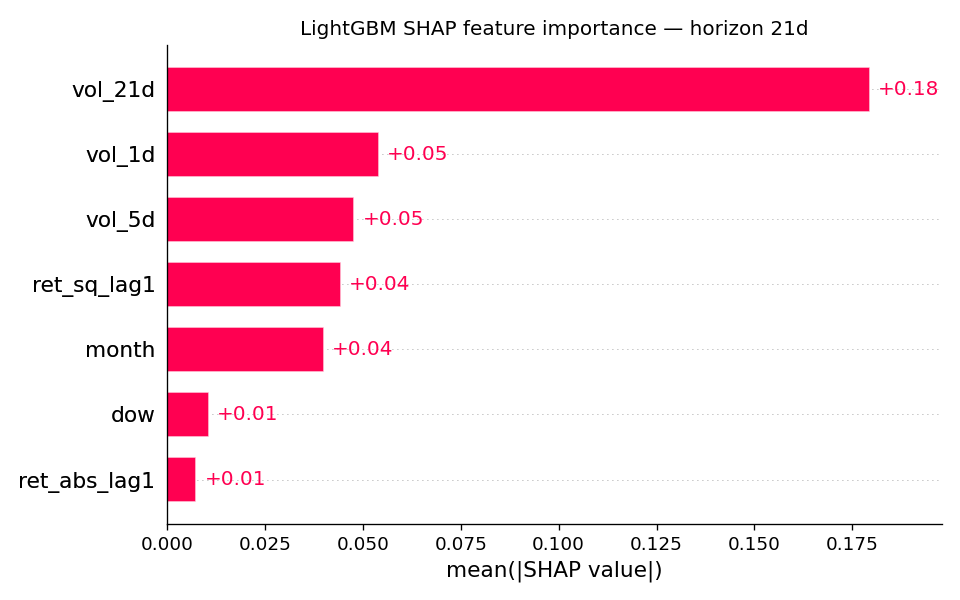

In [17]:
from IPython.display import Image, display
for h in HORIZONS:
    p = PLOT_DIR / f'shap_lgbm_{h}d.png'
    if p.exists():
        print(f'Horizon {h}d:')
        display(Image(filename=str(p)))
    else:
        print(f'Horizon {h}d: no SHAP plot found at {p}')

## QLIKE distribution diagnostics

QLIKE can be dominated by a few extreme cases when predicted variance is tiny. This view
shows the distribution (clipped at the 99th percentile per panel for readability) so you
can tell whether average QLIKE is stable or outlier-driven.

C:\Users\Tunmbi\AppData\Local\Temp\ipykernel_24760\1230232155.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(q_terms, labels=labels, showfliers=False)
C:\Users\Tunmbi\AppData\Local\Temp\ipykernel_24760\1230232155.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(q_terms, labels=labels, showfliers=False)
C:\Users\Tunmbi\AppData\Local\Temp\ipykernel_24760\1230232155.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(q_terms, labels=labels, showfliers=False)


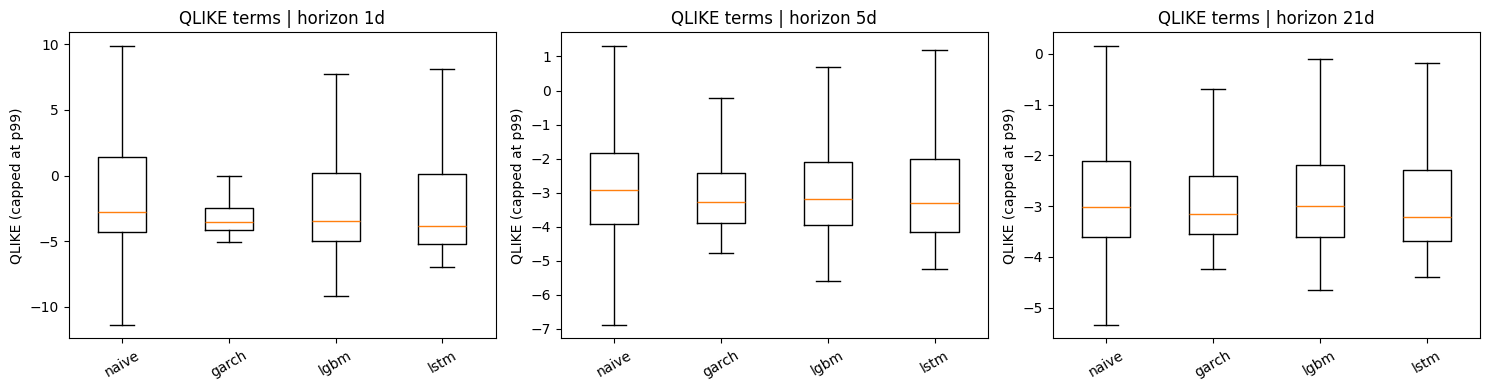

In [18]:
from evaluation.metrics import qlike_terms  # noqa: E402

fig, axes = plt.subplots(1, len(HORIZONS), figsize=(15, 4), sharey=False)
for ax, h in zip(axes, HORIZONS):
    q_terms = []
    labels = []
    for m in MODELS:
        df = load_all(m, h)
        if df.empty:
            continue
        mask = df['y_true'].notna() & df['y_pred'].notna()
        terms = qlike_terms(df.loc[mask, 'y_true'], df.loc[mask, 'y_pred'])
        if terms.size == 0:
            continue
        clip_hi = np.quantile(terms, 0.99)
        q_terms.append(np.clip(terms, None, clip_hi))
        labels.append(m)

    if q_terms:
        ax.boxplot(q_terms, labels=labels, showfliers=False)
        ax.set_title(f'QLIKE terms | horizon {h}d')
        ax.set_ylabel('QLIKE (capped at p99)')
        ax.tick_params(axis='x', rotation=30)
    else:
        ax.set_title(f'QLIKE terms | horizon {h}d (no data)')

plt.tight_layout()
plt.show()

## Per-fold metric breakdown

Useful for spotting whether a single fold (e.g. the COVID-shock fold) is dominating the
aggregate numbers.

In [ ]:
from evaluation.metrics import all_metrics  # noqa: E402

rows = []
for m in MODELS:
    for h in HORIZONS:
        df = load_all(m, h)
        if df.empty:
            continue
        for fold, sub in df.groupby('fold'):
            mask = sub['y_true'].notna() & sub['y_pred'].notna()
            if not mask.any():
                continue
            metrics = all_metrics(sub.loc[mask, 'y_true'], sub.loc[mask, 'y_pred'])
            rows.append({'model': m, 'horizon': h, 'fold': fold, **metrics})

fold_metrics = pd.DataFrame(rows)
fold_metrics

,model,horizon,fold,rmse,qlike,qlike_median,qlike_trimmed_1pct,dir_acc
0,naive,1,0,1.683530,159.432519,-3.168571,59.044423,0.329289
1,naive,1,1,1.671048,144.411837,-2.788358,54.003317,0.323529
2,naive,1,2,1.656928,113.985640,-3.352112,30.772508,0.351820
3,naive,1,3,1.505149,104.244824,-2.430501,29.222718,0.317789
4,naive,1,4,1.581304,132.595304,-2.186202,32.429749,0.307958
5,naive,5,0,0.668639,-2.327842,-3.244135,-2.773149,0.426598
6,naive,5,1,0.638129,-1.940745,-3.021897,-2.362755,0.409326
7,naive,5,2,0.702523,-2.364837,-3.624368,-2.770735,0.398964
8,naive,5,3,0.668530,-1.721791,-2.678516,-1.944239,0.395509
9,naive,5,4,0.549109,-1.642717,-2.385032,-2.113557,0.398964


: 